In [1]:
import networkx as nx
import numpy as np
from data import GraphDataset
from data import GC
from networkx.algorithms.graph_hashing import weisfeiler_lehman_graph_hash

/zhome/c2/2/146508/AML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/zhome/c2/2/146508/AML/.venv/lib/python3.12/site-packages/networkx/algorithms/graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributes changed in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)


# Sample 1000 VAE graphs

In [ ]:
import torch

DEVICE = "cpu"
SAVE_DIR = "vae_graph.pt"

from VAEGraph import NodeVAE
model = NodeVAE(node_feat_dim=7, hidden_dim=64, z_dim=32).to(DEVICE) 
# Load model and sample graphs
model.load_state_dict(torch.load("vae_graph.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

vae_graphs = []
for i in range(1000):
    n = GC.sample_num_nodes()
    with torch.no_grad():
        adj = model.sample(n, device=DEVICE)
    adj_np = adj.cpu().numpy()
    G = nx.from_numpy_array((adj_np > 0.5).astype(int))
    vae_graphs.append(G)

In [40]:
n, adj, adj_np

(17,
 tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0

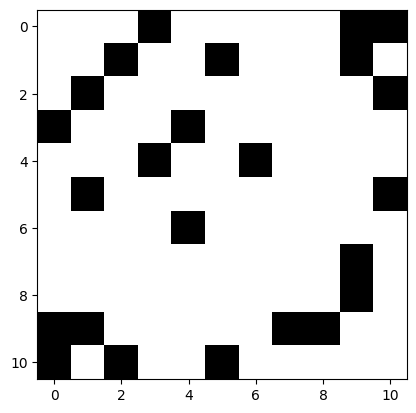

In [31]:
from matplotlib import pyplot as plt
plt.imshow(nx.to_numpy_array(valid_vae_graphs[0]), cmap="Greys", vmin=0, vmax=1)
plt.show()

## Novelty & Unique

In [33]:
novel_generated_graphs = []
unique_hashes = set()

novel_and_unique = []

for sample in valid_vae_graphs:
    sample_hash = weisfeiler_lehman_graph_hash(sample, iterations=100)
    if sample_hash in GC.hashes:
        print("Found a duplicate graph in the baseline samples!")
    else:
        novel_generated_graphs.append(sample)
        if sample_hash not in unique_hashes:
            novel_and_unique.append(sample)
    unique_hashes.add(sample_hash)

print(f"Number of novel generated graphs: {len(novel_generated_graphs)}")
print(f"Number of unique generated graphs: {len(unique_hashes)}")
print(f"Number of novel and unique graphs in baseline samples: {len(novel_and_unique)}")


Number of novel generated graphs: 1000
Number of unique generated graphs: 994
Number of novel and unique graphs in baseline samples: 994


# Graph Statistics

Node Degree  

Node Centrality  

Eigenvector Centrality    


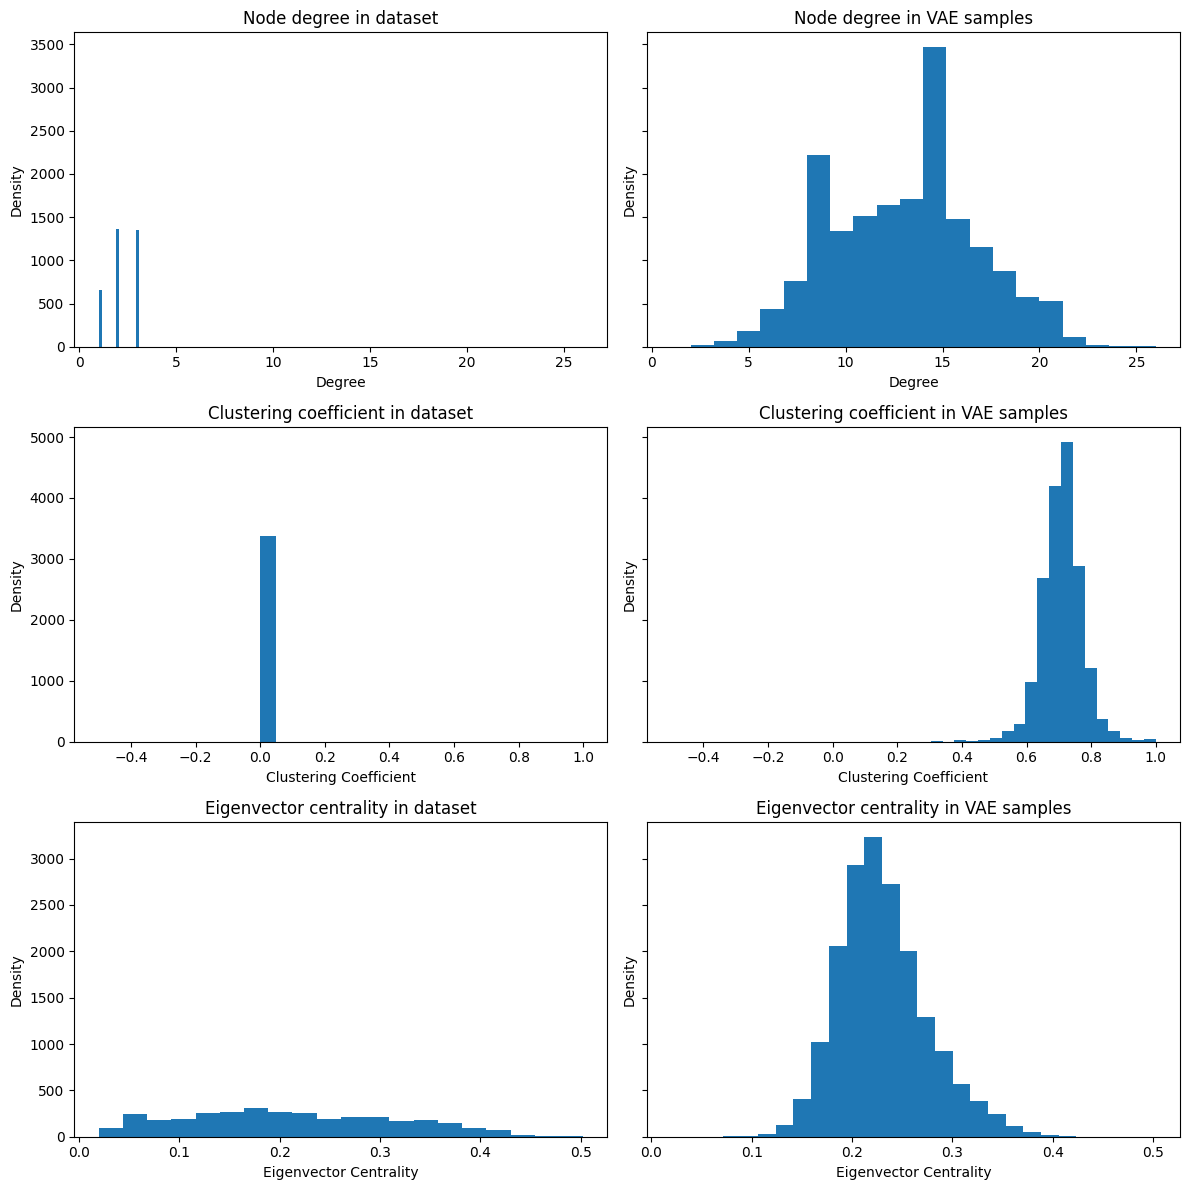

In [10]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a 3x2 grid (increased height to accommodate the third row)
fig, axs = plt.subplots(3, 2, figsize=(12, 12), sharex='row', sharey='row')

def plot_distribution(ax, graphs, metric, title, xlabel):
    values = []
    for graph in graphs:
        if metric == 'degree':
            values.extend(dict(graph.degree()).values())
        elif metric == 'clustering':
            values.extend(list(nx.clustering(graph).values()))
        elif metric == 'eigenvector':
            # max_iter is increased to 1000 to prevent convergence errors on complex graphs
            values.extend(list(nx.eigenvector_centrality(graph, max_iter=10000).values()))
            
    ax.hist(values, bins=20, density=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

# 1. Degree Distributions (Top Row)
plot_distribution(axs[0, 0], GC.networkx_graphs, 'degree', 
                  "Node degree in dataset", "Degree")
plot_distribution(axs[0, 1], vae_graphs, 'degree', 
                  "Node degree in VAE samples", "Degree")

# 2. Clustering Coefficient Distributions (Middle Row)
plot_distribution(axs[1, 0], GC.networkx_graphs, 'clustering', 
                  "Clustering coefficient in dataset", "Clustering Coefficient")
plot_distribution(axs[1, 1], vae_graphs, 'clustering', 
                  "Clustering coefficient in VAE samples", "Clustering Coefficient")

# 3. Eigenvector Centrality Distributions (Bottom Row)
plot_distribution(axs[2, 0], GC.networkx_graphs, 'eigenvector', 
                  "Eigenvector centrality in dataset", "Eigenvector Centrality")
plot_distribution(axs[2, 1], vae_graphs, 'eigenvector', 
                  "Eigenvector centrality in VAE samples", "Eigenvector Centrality")

plt.tight_layout()
plt.show()